In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0026.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0040.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0056.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0009.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0011.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0018.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0005.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0051.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0014.npy
/kaggle/input/datasets/jorgeoc

In [2]:
import os
import glob
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

ROOT = "/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2"
IDIR = os.path.join(ROOT, "intent_dataset")

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

X_files = sorted(glob.glob(os.path.join(IDIR, "X_*.npy")))
Y_files = sorted(glob.glob(os.path.join(IDIR, "Y_*.npy")))

print("IDIR:", IDIR)
print("shards X:", len(X_files))
print("shards Y:", len(Y_files))
print("Ejemplo X:", X_files[:3])
print("Ejemplo Y:", Y_files[:3])

if len(X_files) == 0 or len(Y_files) == 0:
    raise FileNotFoundError(f"No se encontraron shards en {IDIR}")

IDIR: /kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset
shards X: 57
shards Y: 57
Ejemplo X: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0001.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0002.npy']
Ejemplo Y: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0001.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0002.npy']


In [3]:
x0 = np.load(X_files[0], mmap_mode="r")
y0 = np.load(Y_files[0], mmap_mode="r")

print(x0.shape, x0.dtype)
print(y0.shape, y0.dtype)
print("pos frac shard0:", y0.mean())

(20000, 1, 400) float32
(20000,) float32
pos frac shard0: 0.40845


In [4]:
# =========================
# CELDA 1: Dataset + utils
# =========================
import os
import glob
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

ROOT = "/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2"
IDIR = os.path.join(ROOT, "intent_dataset")

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

X_files = sorted(glob.glob(os.path.join(IDIR, "X_*.npy")))
Y_files = sorted(glob.glob(os.path.join(IDIR, "Y_*.npy")))

print("IDIR:", IDIR)
print("shards X:", len(X_files))
print("shards Y:", len(Y_files))
print("Ejemplo X:", X_files[:3])
print("Ejemplo Y:", Y_files[:3])

if len(X_files) == 0 or len(Y_files) == 0:
    raise FileNotFoundError(f"No se encontraron shards en {IDIR}")

print("shards:", len(X_files))

class ShardedIntentDataset(Dataset):
    def __init__(self, X_files, Y_files, max_per_shard=None, seed=123):
        self.samples = []
        rng = np.random.default_rng(seed)

        for xf, yf in zip(X_files, Y_files):
            X = np.load(xf, mmap_mode="r")
            Y = np.load(yf, mmap_mode="r")
            n = len(X)

            idx = np.arange(n)
            if max_per_shard is not None and n > max_per_shard:
                idx = rng.choice(idx, size=max_per_shard, replace=False)

            for i in idx:
                self.samples.append((xf, yf, int(i)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        xf, yf, i = self.samples[idx]
        X = np.load(xf, mmap_mode="r")
        Y = np.load(yf, mmap_mode="r")
        x = torch.tensor(X[i], dtype=torch.float32)   # (1, T)
        y = torch.tensor([Y[i]], dtype=torch.float32) # (1,)
        return x, y

def split_files(files, frac_val=0.15, seed=123):
    idx = np.arange(len(files))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)

    n_val = max(1, int(len(files) * frac_val))
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]

    return tr_idx, val_idx

def binary_metrics_from_probs(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true).astype(np.int32)
    y_prob = np.asarray(y_prob).astype(np.float32)
    y_pred = (y_prob >= thr).astype(np.int32)

    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    acc = (tp + tn) / max(len(y_true), 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-8)

    return {
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn
    }

def roc_auc_fast(y_true, y_score):
    y_true = np.asarray(y_true).astype(np.int32)
    y_score = np.asarray(y_score).astype(np.float64)

    order = np.argsort(y_score)
    y_true = y_true[order]

    n1 = y_true.sum()
    n0 = len(y_true) - n1
    if n0 == 0 or n1 == 0:
        return float("nan")

    ranks = np.arange(1, len(y_true) + 1)
    sum_ranks_pos = ranks[y_true == 1].sum()
    auc = (sum_ranks_pos - n1 * (n1 + 1) / 2) / (n0 * n1)
    return float(auc)

IDIR: /kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset
shards X: 57
shards Y: 57
Ejemplo X: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0001.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0002.npy']
Ejemplo Y: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0001.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0002.npy']
shards: 57


In [5]:
# =========================
# CELDA 2: Modelo TCN
# =========================
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, dilation=1, drop=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(drop)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        s = self.skip(x)
        x = self.drop(self.act(self.bn1(self.conv1(x))))
        x = self.drop(self.act(self.bn2(self.conv2(x))))
        return self.act(x + s)

class IntentTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )
        self.tcn = nn.Sequential(
            TCNBlock(16, 16, dilation=1, drop=0.10),
            TCNBlock(16, 32, dilation=2, drop=0.10),
            TCNBlock(32, 32, dilation=4, drop=0.10),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.tcn(x)
        x = self.pool(x)
        return self.head(x)

In [6]:
# =========================
# CELDA 3: Entrenamiento
# =========================
idx_tr, idx_val = split_files(X_files, frac_val=0.15, seed=SEED)

X_train = [X_files[i] for i in idx_tr]
Y_train = [Y_files[i] for i in idx_tr]
X_val   = [X_files[i] for i in idx_val]
Y_val   = [Y_files[i] for i in idx_val]

train_ds = ShardedIntentDataset(X_train, Y_train, max_per_shard=4000, seed=1)
val_ds   = ShardedIntentDataset(X_val, Y_val, max_per_shard=4000, seed=2)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

model = IntentTCN().to(device)


# manejar desbalance
y_pos_frac = []
for yf in Y_train:
    y_pos_frac.append(np.load(yf, mmap_mode="r").mean())

approx_pos = float(np.mean(y_pos_frac))
pos_weight_value = (1.0 - approx_pos) / max(approx_pos, 1e-6)
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

print("approx_pos:", approx_pos, "pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    losses, ys, ps = [], [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)
        p = torch.sigmoid(logits)

        losses.append(loss.item() * x.size(0))
        ys.append(y.cpu().numpy().reshape(-1))
        ps.append(p.cpu().numpy().reshape(-1))

    ys = np.concatenate(ys)
    ps = np.concatenate(ps)
    loss = np.sum(losses) / max(len(ys), 1)
    mets = binary_metrics_from_probs(ys, ps, thr=0.5)
    mets["auc"] = roc_auc_fast(ys, ps)
    mets["loss"] = loss
    return mets, ys, ps

history = {
    "train_loss": [], "val_loss": [],
    "val_acc": [], "val_f1": [], "val_auc": []
}

best_state = None
best_score = -1
patience = 5
bad_epochs = 0
EPOCHS = 25

for ep in range(1, EPOCHS + 1):
    model.train()
    t0 = time.time()
    train_loss_sum = 0.0
    n_seen = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * x.size(0)
        n_seen += x.size(0)

    train_loss = train_loss_sum / max(n_seen, 1)
    val_mets, yv, pv = evaluate(val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_mets["loss"])
    history["val_acc"].append(val_mets["acc"])
    history["val_f1"].append(val_mets["f1"])
    history["val_auc"].append(val_mets["auc"])

    score = 0.6 * val_mets["f1"] + 0.4 * val_mets["auc"]

    print(
        f"Epoch {ep:02d} | "
        f"train_loss={train_loss:.4f} | val_loss={val_mets['loss']:.4f} | "
        f"acc={val_mets['acc']:.4f} | f1={val_mets['f1']:.4f} | auc={val_mets['auc']:.4f} | "
        f"prec={val_mets['precision']:.4f} | rec={val_mets['recall']:.4f} | "
        f"time={time.time()-t0:.1f}s"
    )

    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_state)
torch.save(model.state_dict(), "/kaggle/working/intent_binary_best.pt")
print("Guardado: /kaggle/working/intent_binary_best.pt")

device: cuda
approx_pos: 0.5573095679283142 pos_weight: 0.794334888458252
Epoch 01 | train_loss=0.4034 | val_loss=0.4205 | acc=0.7900 | f1=0.7784 | auc=0.8437 | prec=0.8336 | rec=0.7301 | time=1076.4s
Epoch 02 | train_loss=0.3970 | val_loss=0.4127 | acc=0.7910 | f1=0.7702 | auc=0.8451 | prec=0.8660 | rec=0.6935 | time=910.5s
Epoch 03 | train_loss=0.3946 | val_loss=0.4083 | acc=0.7881 | f1=0.7681 | auc=0.8508 | prec=0.8589 | rec=0.6947 | time=870.6s
Epoch 04 | train_loss=0.3926 | val_loss=0.4032 | acc=0.7905 | f1=0.7728 | auc=0.8556 | prec=0.8547 | rec=0.7052 | time=867.8s
Epoch 05 | train_loss=0.3912 | val_loss=0.3972 | acc=0.7951 | f1=0.7757 | auc=0.8575 | prec=0.8677 | rec=0.7012 | time=907.9s
Epoch 06 | train_loss=0.3899 | val_loss=0.4016 | acc=0.7959 | f1=0.7800 | auc=0.8564 | prec=0.8563 | rec=0.7162 | time=893.2s
Epoch 07 | train_loss=0.3890 | val_loss=0.4018 | acc=0.7891 | f1=0.7621 | auc=0.8573 | prec=0.8855 | rec=0.6690 | time=861.5s
Epoch 08 | train_loss=0.3891 | val_loss=0.3

Métricas finales val: {'acc': 0.8006875, 'precision': 0.857727737973388, 'recall': 0.7258104429596635, 'f1': 0.7862743783928691, 'tp': 11732, 'tn': 13890, 'fp': 1946, 'fn': 4432, 'auc': 0.8609097266719085, 'loss': np.float64(0.3959737024307251)}


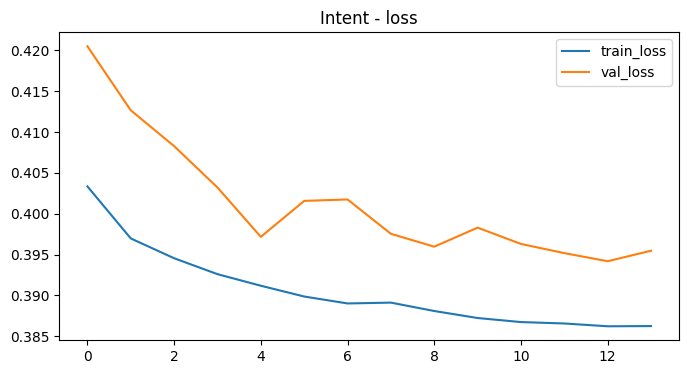

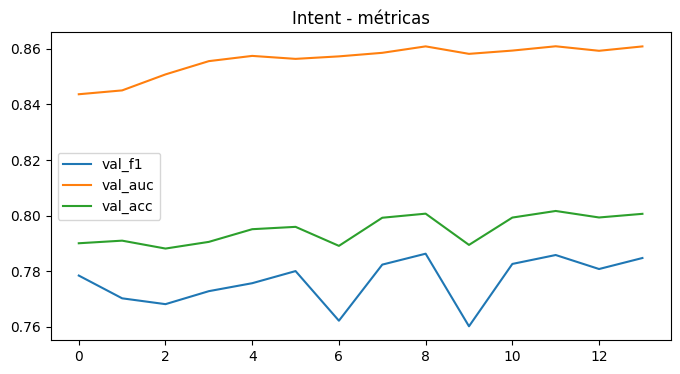

TP, TN, FP, FN = (11732, 13890, 1946, 4432)


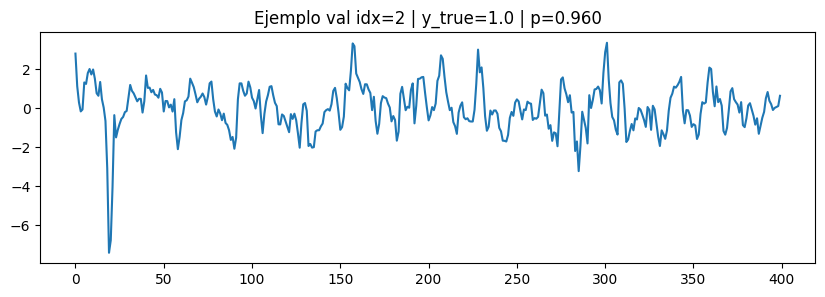

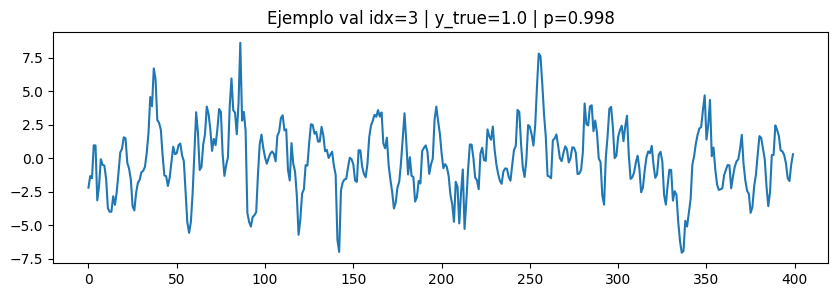

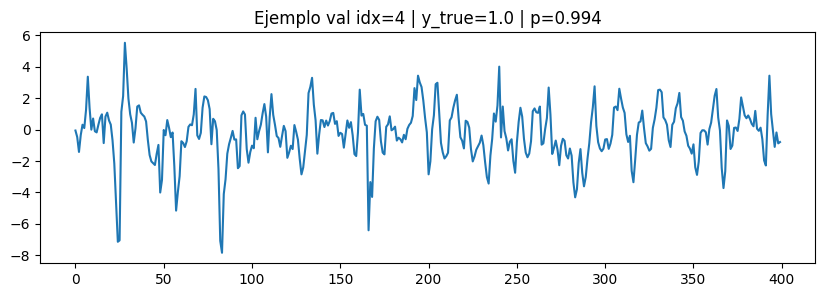

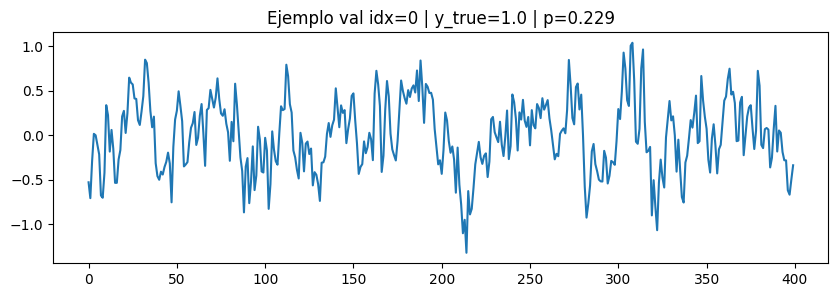

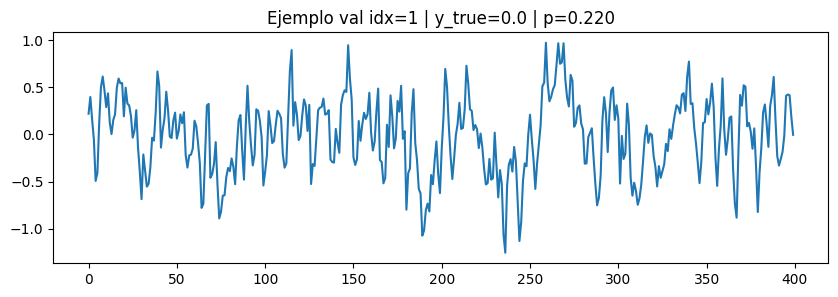

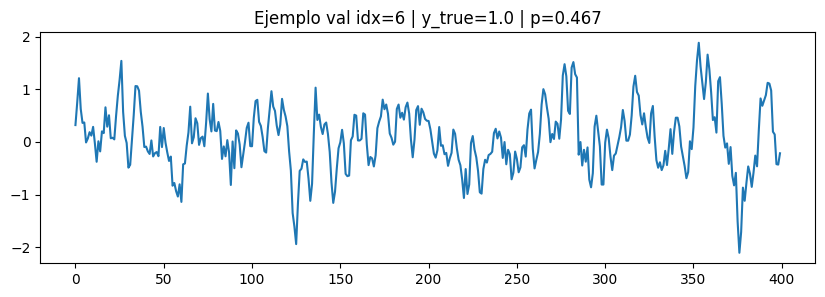

In [7]:
# =========================
# CELDA 4: Gráficas
# =========================
val_mets, yv, pv = evaluate(val_loader)
print("Métricas finales val:", val_mets)

plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Intent - loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["val_f1"], label="val_f1")
plt.plot(history["val_auc"], label="val_auc")
plt.plot(history["val_acc"], label="val_acc")
plt.title("Intent - métricas")
plt.legend()
plt.show()

cm = val_mets["tp"], val_mets["tn"], val_mets["fp"], val_mets["fn"]
print("TP, TN, FP, FN =", cm)

yhat = (pv >= 0.5).astype(int)
idx_pos = np.where(yhat == 1)[0][:3]
idx_neg = np.where(yhat == 0)[0][:3]

# visualizar ejemplos
all_x = []
for x, y in val_loader:
    all_x.append(x.numpy())
all_x = np.concatenate(all_x, axis=0)

for i in list(idx_pos) + list(idx_neg):
    plt.figure(figsize=(10,3))
    plt.plot(all_x[i,0])
    plt.title(f"Ejemplo val idx={i} | y_true={yv[i]} | p={pv[i]:.3f}")
    plt.show()